LOADING THE DATASET-1

In [11]:
import pandas as pd
df=pd.read_csv(r"C:\Users\prave\Downloads\electronics review\Electronics_5_part0.csv")
df.head(5)

,asin,reviewText,overall,category,summary
0,0151004714,This is the best novel I have read in 2 or 3 y...,5.0,Electronics_5,A star is born
1,0151004714,"Pages and pages of introspection, in the style...",3.0,Electronics_5,A stream of consciousness novel
2,0151004714,This is the kind of novel to read when you hav...,5.0,Electronics_5,I'm a huge fan of the author and this one did ...
3,0151004714,What gorgeous language! What an incredible wri...,5.0,Electronics_5,The most beautiful book I have ever read!
4,0151004714,I was taken in by reviews that compared this b...,3.0,Electronics_5,A dissenting view--In part.


In [12]:
df.tail(5)

,asin,reviewText,overall,category,summary
3778156,B00HV6KIEY,I use bridge cameras because I don't know anyt...,4.0,Electronics_5,As a bridge camera user without photography sk...
3778157,B00HV5KYSK,I got the touch screen pens for my family and ...,5.0,Electronics_5,Mini Stylus pen greate for the kids with pads ...
3778158,B00HV5KYSK,These stylus work well. They fit into pocket ...,4.0,Electronics_5,Small stylus works well
3778159,B00HV5KYSK,"work just fine, takes a while to deliver (from...",5.0,Electronics_5,Nice stylus collection
3778160,B00HV5KYSK,"I love these little gadgets, they are so much ...",5.0,Electronics_5,Great invention


In [13]:
df.sample(5)

,asin,reviewText,overall,category,summary
1181729,B0024OF15Y,"shipping blew, item sort of worked. only blac...",5.0,Electronics_5,sucked
3427363,B00ELJVM5I,Super cool!,5.0,Electronics_5,Very durable and easy to install
3725264,B00HEU1JGI,Works and gives the option to charge the wife'...,5.0,Electronics_5,Beats carrying Apple and Android cables
3106937,B00CC7UKMM,Received two of these very attractive styli as...,3.0,Electronics_5,Looks great - - BUT!!
1935934,B005C2A34E,Great!,5.0,Electronics_5,Five Stars


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3778161 entries, 0 to 3778160
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   asin        object 
 1   reviewText  object 
 2   overall     float64
 3   category    object 
 4   summary     object 
dtypes: float64(1), object(4)
memory usage: 144.1+ MB


In [15]:
df.describe()

,overall
count,3.778161e+06
mean,4.273313e+00
std,1.189414e+00
min,1.000000e+00
25%,4.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [16]:
df.shape

(3778161, 5)

COLUMNS NAMES

In [ ]:
df.columns

Index(['asin', 'reviewText', 'overall', 'category', 'summary'], dtype='object')

In [18]:
pip install  wordcloud 

Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------- ----- 1.3/1.5 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.2 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [click]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   -----------------------

DEEP ANALYSIS

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob


# Combine reviewText and summary
df['full_text'] = df['reviewText'].fillna('') + " " + df['summary'].fillna('')

# Clean ratings
df = df[df['overall'].notnull()]
df['overall'] = df['overall'].astype(int)


WORD CLOUDS FOR HIGH VS. LOW RATINGS

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


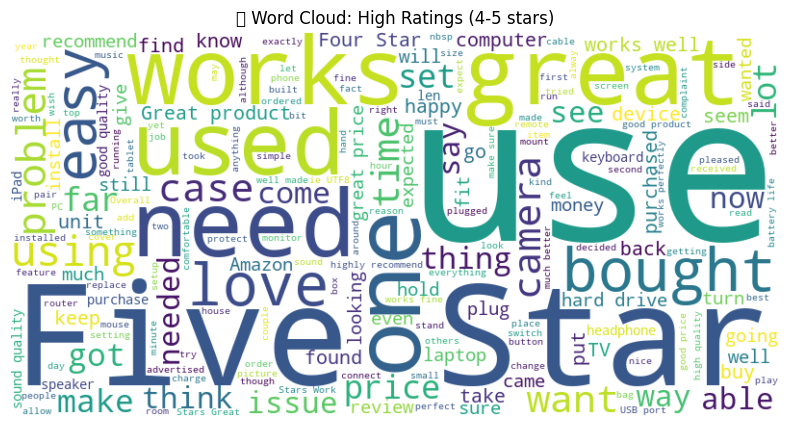

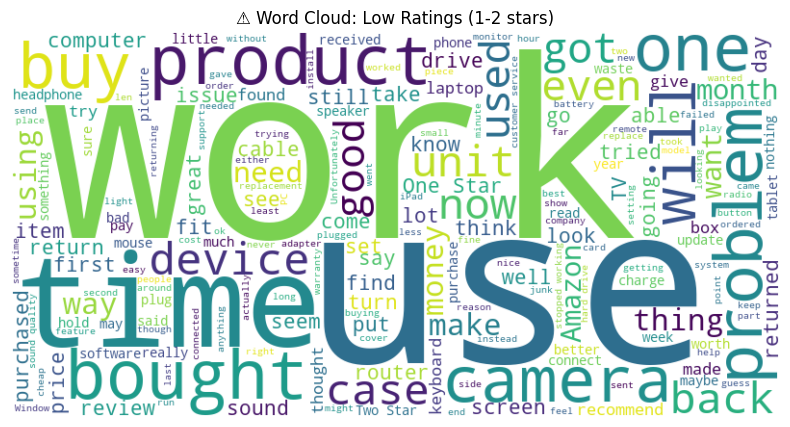

In [22]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

high_reviews = df[df['overall'] >= 4]['full_text']
low_reviews = df[df['overall'] <= 2]['full_text']

generate_wordcloud(high_reviews, "🌟 Word Cloud: High Ratings (4-5 stars)")
generate_wordcloud(low_reviews, "⚠️ Word Cloud: Low Ratings (1-2 stars)")


KEYWORD FREQUENCY FOR 1-STAR VS. 5-STAR

In [25]:
pip install spacy


   ---------------------------------------- 0.0/13.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.9 MB ? eta -:--:--
    --------------------------------------- 0.3/13.9 MB ? eta -:--:--
    --------------------------------------- 0.3/13.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.9 MB 680.5 kB/s eta 0:00:20
   -- ------------------------------------- 0.8/13.9 MB 703.9 kB/s eta 0:00:19
   -- ------------------------------------- 0.8/13.9 MB 703.9 kB/s eta 0:00:19
   --- ------------------------------------ 1.0/13.9 MB 750.6 kB/s eta 0:00:18
   --- ------------------------------------ 1.3/13.9 MB 790.8 kB/s eta 0:00:16
   ---- ----------------------------------- 1.6/13.9 MB 831.6 kB/s eta 0:00:15
   ----- ---------------------------------- 1.8/13.9 MB 867.6 kB/s eta 0:00:14
   ------ --------------------------------- 2.1/13.9 MB 927.3 kB/s eta 0:00:13
   ------ --------

In [30]:
!python -m spacy download en_core_web_sm



     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 623.6 kB/s eta 0:00:20
     - ------------------------------------- 0.5/12.8 MB 623.6 kB/s eta 0:00:20
     - ------------------------------------- 0.5/12.8 MB 623.6 kB/s eta 0:00:20
     -- ------------------------------------ 0.8/12.8 MB 512.8 kB/s eta 0:00:24
     -- ------------------------------------ 0.8/12.8 MB 512.8 kB/s eta 0:00:24
     --- ----------------------------------- 1.0/12.8 MB 589.1 kB/s eta 0:00:20
     --- ----------------------------------- 1.3/12.8 MB 668.5 kB/s eta 0:00:18
     --- ----------------------------------- 1.3/12.8 MB 668.5 kB/s eta 0:00:18


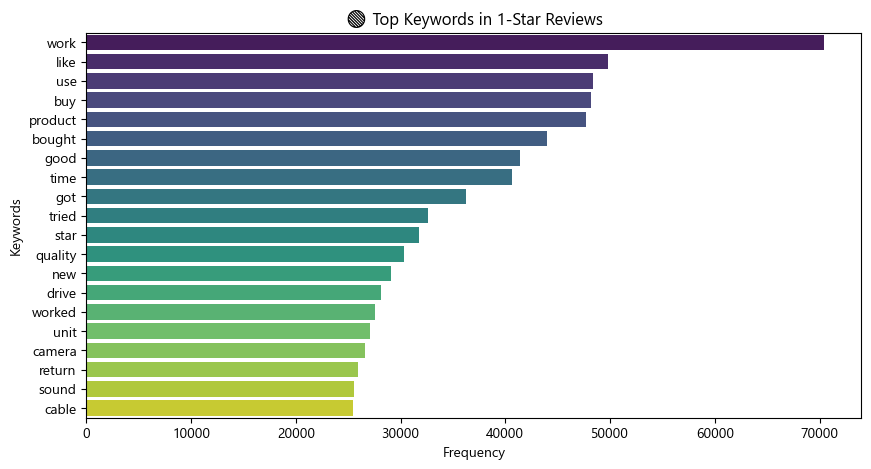

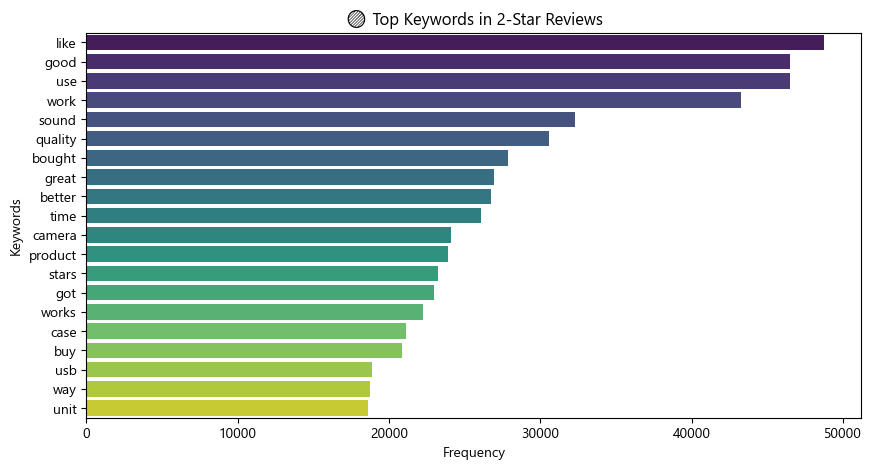

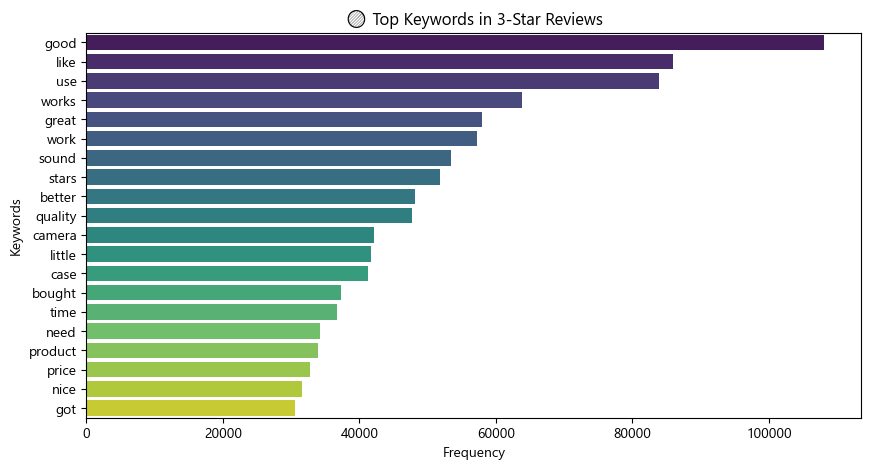

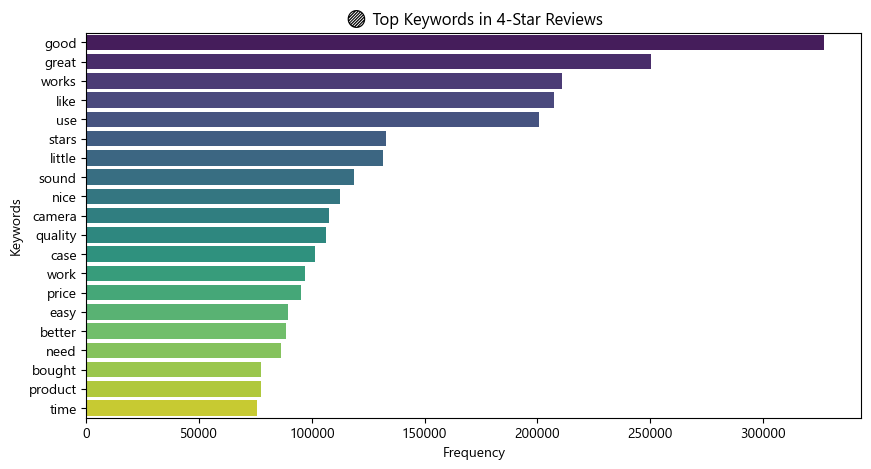

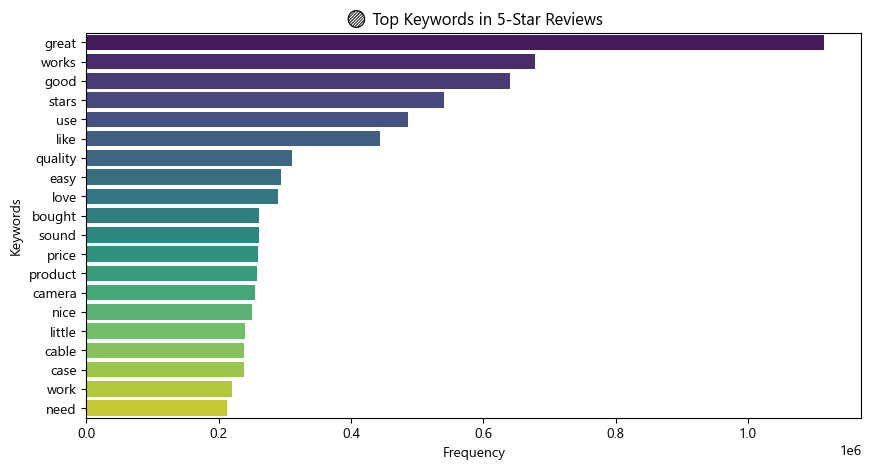

In [33]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Use a font that supports emojis (Windows: Segoe UI Emoji)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Load English model
nlp = spacy.load("en_core_web_sm")

def get_top_keywords(text_series, top_n=20):
    stop_words = spacy.lang.en.stop_words.STOP_WORDS
    words = " ".join(text_series).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(words).most_common(top_n)

# Extract top keywords for each star rating
top_1_star = get_top_keywords(df[df['overall'] == 1]['full_text'])
top_2_star = get_top_keywords(df[df['overall'] == 2]['full_text'])
top_3_star = get_top_keywords(df[df['overall'] == 3]['full_text'])
top_4_star = get_top_keywords(df[df['overall'] == 4]['full_text'])
top_5_star = get_top_keywords(df[df['overall'] == 5]['full_text'])

# Plotting function
def plot_keywords(freq_list, title):
    words, counts = zip(*freq_list)
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),       # assign y to hue
        palette="viridis",
        legend=False           # hide redundant legend
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Keywords")
    plt.show()

# Generate plots
plot_keywords(top_1_star, "🔴 Top Keywords in 1-Star Reviews")
plot_keywords(top_2_star, "🟠 Top Keywords in 2-Star Reviews")
plot_keywords(top_3_star, "🟡 Top Keywords in 3-Star Reviews")
plot_keywords(top_4_star, "🟣 Top Keywords in 4-Star Reviews")
plot_keywords(top_5_star, "🟢 Top Keywords in 5-Star Reviews")


SENTIMENT VS. RATING CONSISTENCY

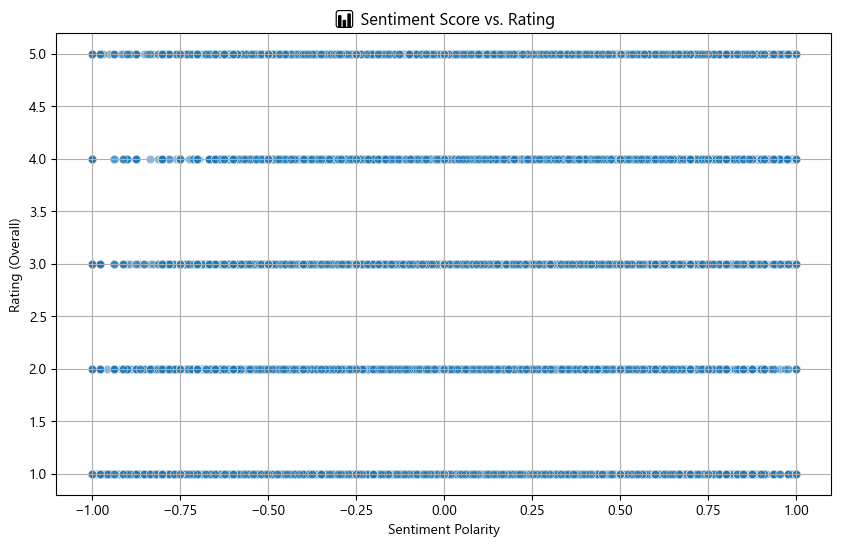

In [35]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['full_text'].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sentiment', y='overall', alpha=0.5)
plt.title("📊 Sentiment Score vs. Rating")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Rating (Overall)")
plt.grid(True)
plt.show()



REVIEW LENGTH VS. RATING

C:\Users\prave\AppData\Local\Temp\ipykernel_29036\2297037623.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='overall', y='review_length', palette="coolwarm")


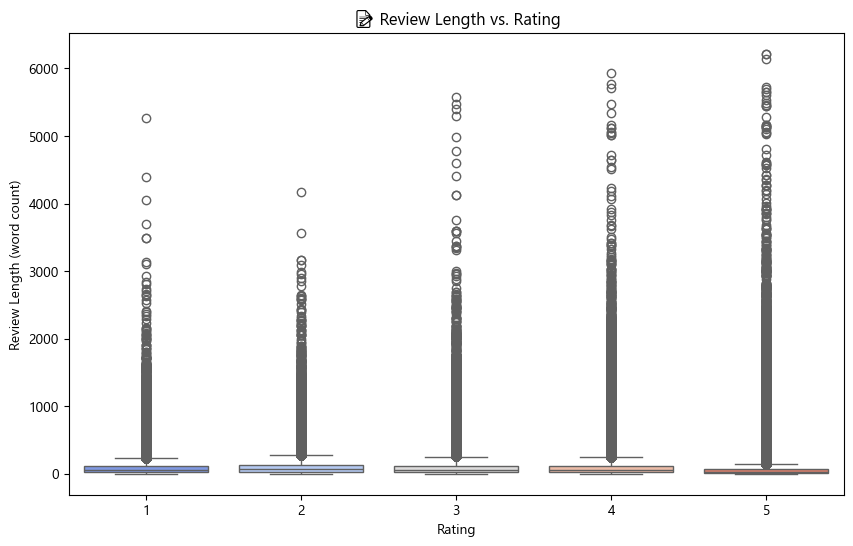

In [36]:
df['review_length'] = df['full_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='overall', y='review_length', palette="coolwarm")
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (word count)")
plt.show()


REMOVING THE UNNECESSARY COLUMNS

In [ ]:
df=df.drop(columns=['asin',  'category', 'summary' ])

CHECKING NULL VALUES

In [ ]:
df.isnull().sum()

,0
reviewText,133
overall,0


REMOVING NULL VALUES

In [ ]:
df.dropna(inplace=True)

CHECKING DUPLICATES

In [ ]:
print(df.duplicated().sum())

406993


DROPPING DUPLICATES

In [ ]:
df.drop_duplicates(subset=['reviewText', 'overall'],inplace=True)

RENAMING THE COLUMNS

In [ ]:
df.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

In [ ]:
df['rating'].astype(int)

,rating
0,5
1,3
2,5
3,5
4,3
...,...
3778156,4
3778157,5
3778158,4
3778159,5


REMOVING EMOJIS,LINKS

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [ ]:
df['rating']=df['rating'].astype(int)

In [ ]:
df['rating'].value_counts()

,count
rating,
5,2082108
4,609672
3,271566
1,241684
2,166005


SORTING THE DATA

In [ ]:
df.sort_values(by='rating',ascending=True,inplace=True)

In [ ]:
df.shape

(3371035, 2)

In [ ]:
df.head(5)

,review,rating
3002577,all of the blue outside covering started peeli...,1
3002563,doa horribly crimped and damaged one jack is a...,1
456013,not sure if it is this product or the bluetoot...,1
456006,is not durable the rubber suction cup deterior...,1
456004,i recently bought a garmin nuvi t my previous ...,1


In [ ]:
df.to_csv('cleaned_electronics_part0.csv',index=False)

LOADING THE DATASET-2

In [37]:
df2=pd.read_csv(r'C:\Users\prave\Downloads\electronics review\Electronics_5_part1.csv')

In [ ]:
df2.head(5)

,asin,reviewText,overall,category,summary
0,B00HV5KYSK,Something ultra cute that does the job? Wow! ...,5.0,Electronics_5,How adorable!
1,B00HV5KYSK,"The product is deceptively simple, but it has ...",5.0,Electronics_5,Excellent buy
2,B00HV5KYSK,I have arthritis in my hands and trying to tex...,5.0,Electronics_5,Makes texting easy
3,B00HV5KYSK,I rated these a 5 star they work very well. I ...,5.0,Electronics_5,Ipad2 items
4,B00HV5KYSK,The mini styli pens that I puchased are excell...,5.0,Electronics_5,Mini Stylus pen


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2722700 entries, 0 to 2722699
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   asin        object 
 1   reviewText  object 
 2   overall     float64
 3   category    object 
 4   summary     object 
dtypes: float64(1), object(4)
memory usage: 103.9+ MB


In [ ]:
df2.describe()

,overall
count,2.722700e+06
mean,4.251393e+00
std,1.230080e+00
min,1.000000e+00
25%,4.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


In [ ]:
df2.shape

(2722700, 5)

COLUMNS NAMES

In [ ]:
df2.columns

Index(['asin', 'reviewText', 'overall', 'category', 'summary'], dtype='object')

DEEP ANALYSIS

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob


# Combine reviewText and summary
df2['full_text'] = df2['reviewText'].fillna('') + " " + df2['summary'].fillna('')

# Clean ratings
df2 = df2[df2['overall'].notnull()]
df2['overall'] = df2['overall'].astype(int)


WORD CLOUDS FOR HIGH VS. LOW RATINGS

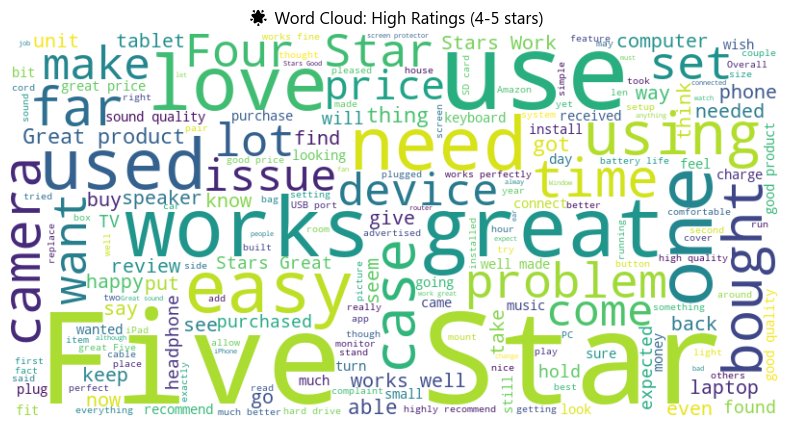

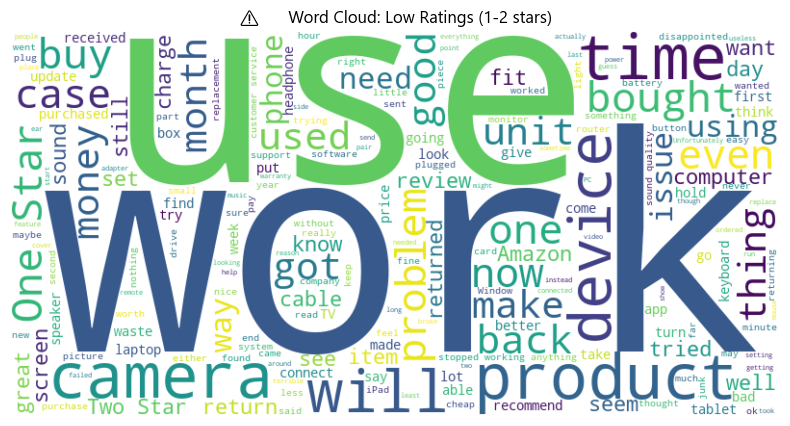

In [39]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

high_reviews = df2[df2['overall'] >= 4]['full_text']
low_reviews = df2[df2['overall'] <= 2]['full_text']

generate_wordcloud(high_reviews, "🌟 Word Cloud: High Ratings (4-5 stars)")
generate_wordcloud(low_reviews, "⚠️ Word Cloud: Low Ratings (1-2 stars)")


KEYWORD FREQUENCY FOR 1-STAR VS. 5-STAR

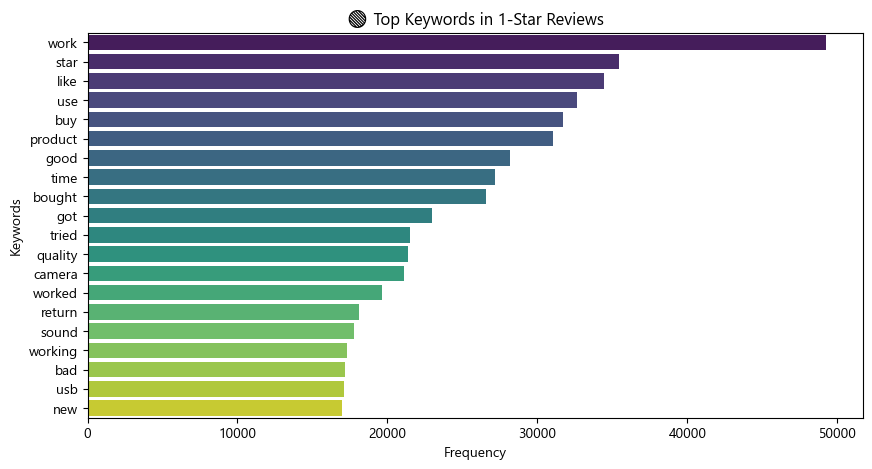

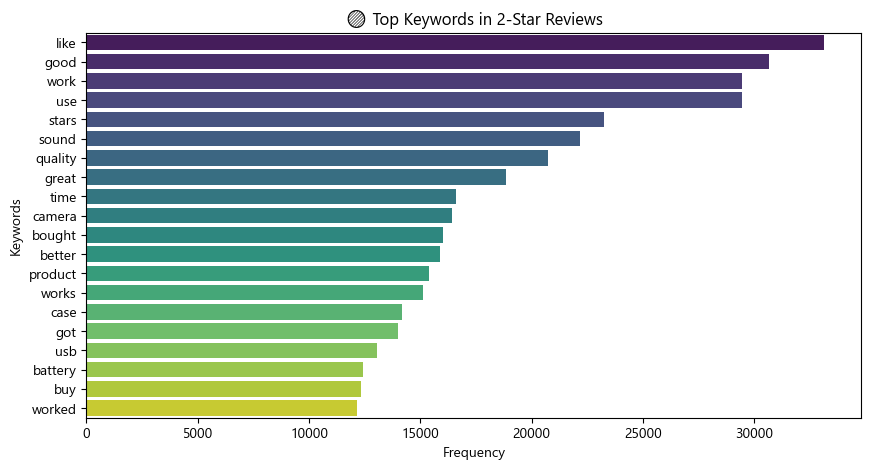

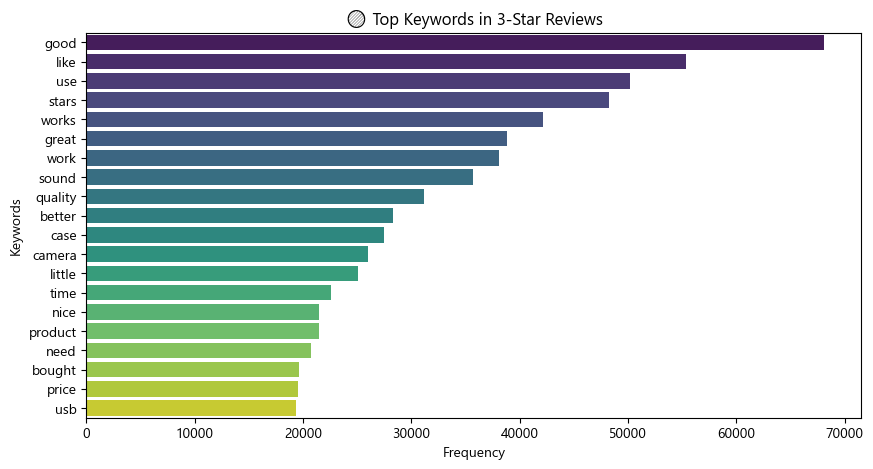

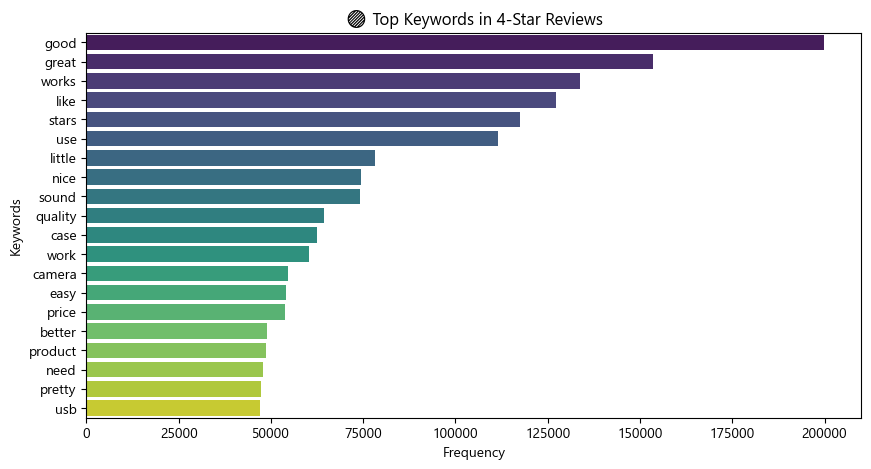

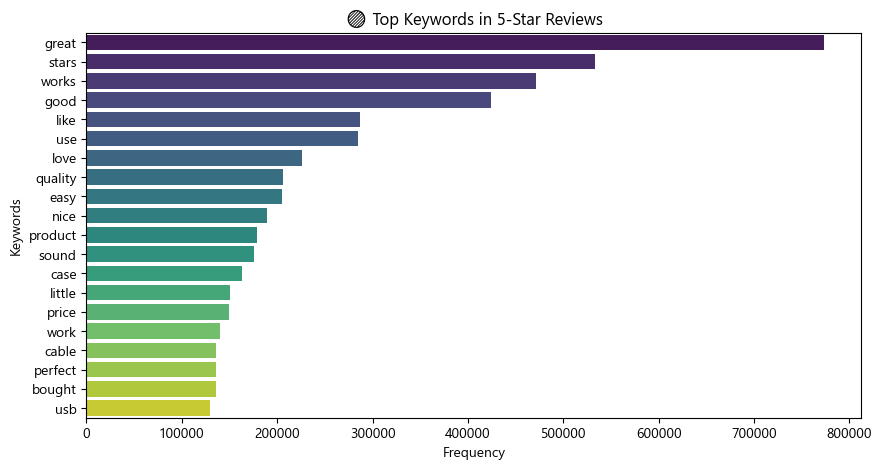

In [40]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Use a font that supports emojis (Windows: Segoe UI Emoji)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Load English model
nlp = spacy.load("en_core_web_sm")

def get_top_keywords(text_series, top_n=20):
    stop_words = spacy.lang.en.stop_words.STOP_WORDS
    words = " ".join(text_series).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(words).most_common(top_n)

# Extract top keywords for each star rating
top_1_star = get_top_keywords(df2[df2['overall'] == 1]['full_text'])
top_2_star = get_top_keywords(df2[df2['overall'] == 2]['full_text'])
top_3_star = get_top_keywords(df2[df2['overall'] == 3]['full_text'])
top_4_star = get_top_keywords(df2[df2['overall'] == 4]['full_text'])
top_5_star = get_top_keywords(df2[df2['overall'] == 5]['full_text'])

# Plotting function
def plot_keywords(freq_list, title):
    words, counts = zip(*freq_list)
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),       # assign y to hue
        palette="viridis",
        legend=False           # hide redundant legend
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Keywords")
    plt.show()

# Generate plots
plot_keywords(top_1_star, "🔴 Top Keywords in 1-Star Reviews")
plot_keywords(top_2_star, "🟠 Top Keywords in 2-Star Reviews")
plot_keywords(top_3_star, "🟡 Top Keywords in 3-Star Reviews")
plot_keywords(top_4_star, "🟣 Top Keywords in 4-Star Reviews")
plot_keywords(top_5_star, "🟢 Top Keywords in 5-Star Reviews")



SENTIMENT VS. RATING CONSISTENCY

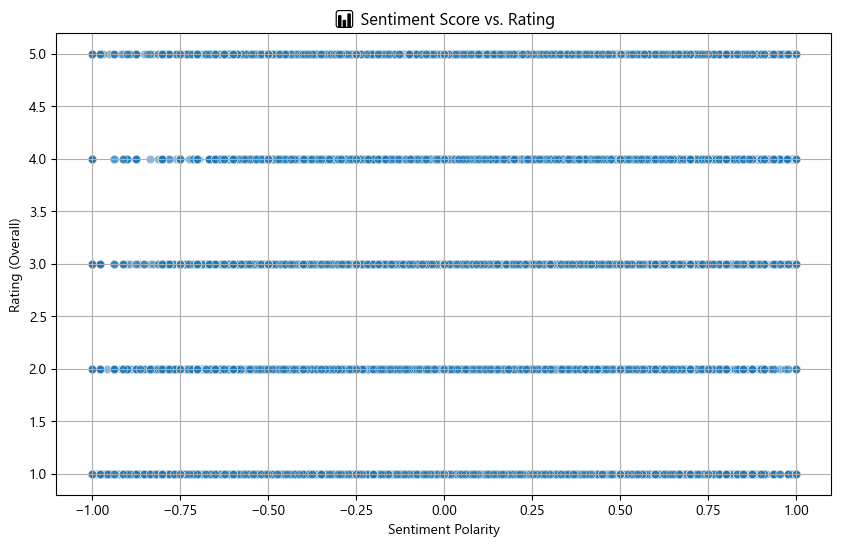

In [43]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df2['sentiment'] = df2['full_text'].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sentiment', y='overall', alpha=0.5)
plt.title("📊 Sentiment Score vs. Rating")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Rating (Overall)")
plt.grid(True)
plt.show()



REVIEW LENGTH VS. RATING

C:\Users\prave\AppData\Local\Temp\ipykernel_29036\22203808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='overall', y='review_length', palette="coolwarm")


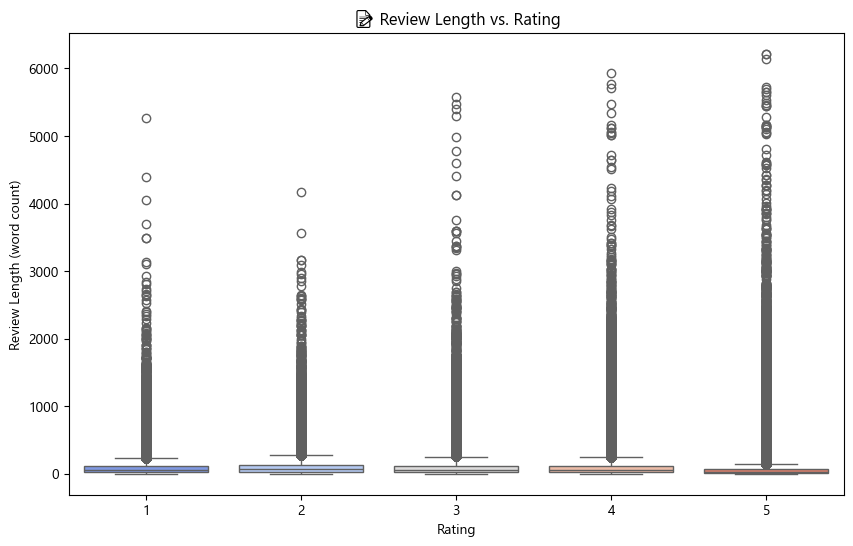

In [45]:
df2['review_length'] = df2['full_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='overall', y='review_length', palette="coolwarm")
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (word count)")
plt.show()


REMOVING THE UNNECESSARY COLUMNS

In [ ]:
df2=df2.drop(columns=['asin', 'category', 'summary' ])

CHECKING NULL VALUES

In [ ]:
df2.isnull().sum()

,0
reviewText,144
overall,0


REMOVING NULL VALUES

In [ ]:
df2.dropna(inplace=True)

CHECKING DUPLICATES

In [ ]:
print(df2.duplicated().sum())

363001


DROPPING DUPLICATES

In [ ]:
df2.drop_duplicates(subset=['reviewText', 'overall'],inplace=True)

RENAMING THE COLUMNS

In [ ]:
df2.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

In [ ]:
df2['rating']=df2['rating'].astype(int)

REMOVING EMOJIS,LINKS

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df2.loc[:, "review"] = df["review"].apply(clean_text)

In [ ]:
df2['rating'].value_counts()

,count
rating,
5,1459880
4,392232
1,192329
3,191265
2,123849


SORTING THE DATA

In [ ]:
df2.sort_values(by='rating',ascending=True,inplace=True)

In [ ]:
df2.shape

(2359555, 2)

In [ ]:
df2.to_csv('cleaned_electronics_part1.csv',index=False)

LOADING THE DATASET-3

In [2]:
import pandas as pd
df3=pd.read_csv(r'C:\Users\prave\Downloads\electronics review\electronics_small.csv')

C:\Users\prave\AppData\Local\Temp\ipykernel_19136\2808830424.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df3=pd.read_csv(r'C:\Users\prave\Downloads\electronics review\electronics_small.csv')


In [ ]:
df3.head(5)

,overall,vote,verified,reviewTime,reviewText,summary
0,5,67,True,1999-09-18,This is the best novel I have read in 2 or 3 y...,A star is born
1,3,5,True,2013-10-23,"Pages and pages of introspection, in the style...",A stream of consciousness novel
2,5,4,True,2008-09-02,This is the kind of novel to read when you hav...,I'm a huge fan of the author and this one did ...
3,5,13,True,2000-09-04,What gorgeous language! What an incredible wri...,The most beautiful book I have ever read!
4,3,8,True,2000-02-04,I was taken in by reviews that compared this b...,A dissenting view--In part.


In [ ]:
df3.sample(5)

,overall,vote,verified,reviewTime,reviewText,summary
1443537,5,0,True,2015-05-25,Five Stars,1432512000
491382,5,0,True,2009-04-06,This is a great mixer for a very low price.\n\...,Great Small Mixer
996567,5,0,True,2012-06-07,"Good Kit, excellent price",1339027200
426296,5,0,True,2009-06-28,I have been using this for a couple of months ...,So glad I bought this!
35121,2,0,True,2016-09-21,"It works, but my husband has a large wrist. Al...",the alligator clip pops off the connector way ...


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 6 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   overall     int64 
 1   vote        int64 
 2   verified    bool  
 3   reviewTime  object
 4   reviewText  object
 5   summary     object
dtypes: bool(1), int64(2), object(3)
memory usage: 117.3+ MB


In [ ]:
df3.describe()

,overall,vote
count,3.000000e+06,3.000000e+06
mean,4.263818e+00,1.768431e+00
std,1.200790e+00,2.094736e+01
min,1.000000e+00,0.000000e+00
25%,4.000000e+00,0.000000e+00
50%,5.000000e+00,0.000000e+00
75%,5.000000e+00,0.000000e+00
max,5.000000e+00,9.096000e+03


In [ ]:
df3.shape

(3000000, 6)

COLUMNS NAMES

In [ ]:
df3.columns

Index(['overall', 'vote', 'verified', 'reviewTime', 'reviewText', 'summary'], dtype='object')

DEEP ANALYSIS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from datetime import datetime

PREPARE DATA

In [48]:
# Combine reviewText and summary
df3['reviewText']=df3['reviewText'].astype(str)
df3['summary']=df3['summary'].astype(str)
df3['full_text'] = df3['reviewText'].fillna('') + " " + df3['summary'].fillna('')

# Convert reviewTime to datetime
df3['reviewTime'] = pd.to_datetime(df3['reviewTime'], errors='coerce')

# Clean ratings
df3 = df3[df3['overall'].notnull()]
df3['overall'] = df3['overall'].astype(int)

SENTIMENT VS RATING CONSISTENCY  

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


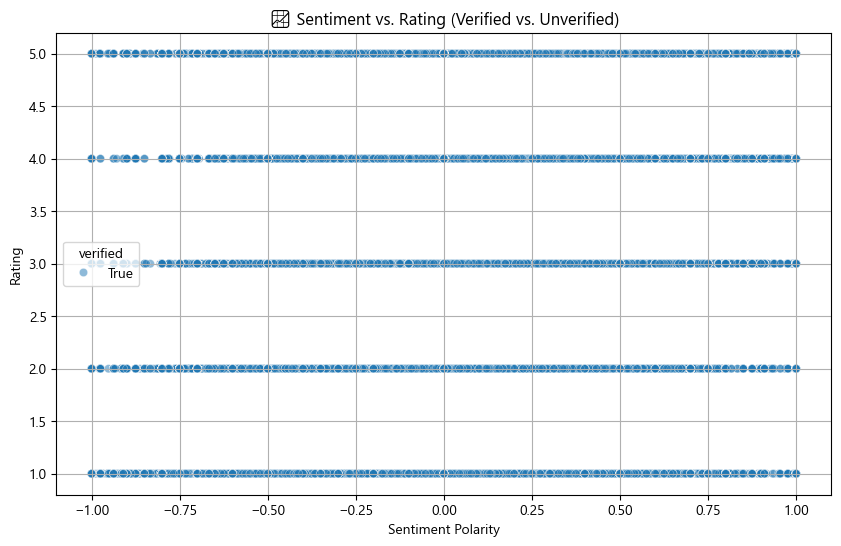

In [50]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df3['sentiment'] = df3['full_text'].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df3, x='sentiment', y='overall', hue='verified', alpha=0.5)
plt.title("📈 Sentiment vs. Rating (Verified vs. Unverified)")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Rating")
plt.grid(True)
plt.show()

RATING TRENDS OVER TIME

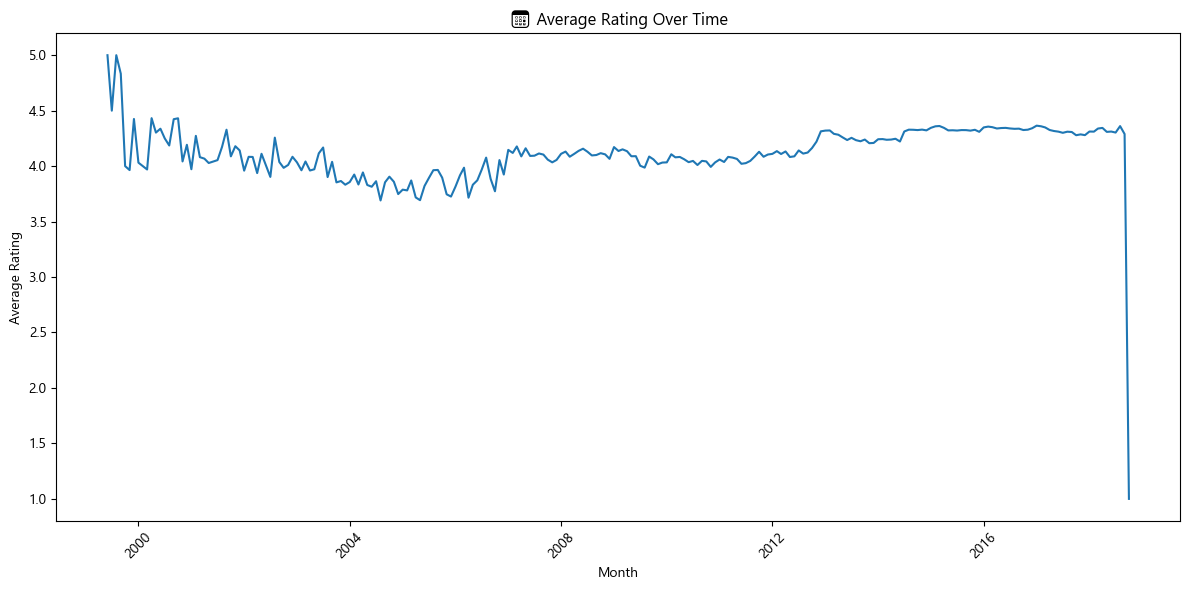

In [56]:
df3['year_month'] = df3['reviewTime'].dt.to_period('M')
monthly_avg = df3.groupby('year_month')['overall'].mean().reset_index()

# Convert Period to datetime
monthly_avg['year_month'] = monthly_avg['year_month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='year_month', y='overall')
plt.title("📅 Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


REVIEW HELPFULNESS VS. RATING

C:\Users\prave\AppData\Local\Temp\ipykernel_29036\2882077879.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df3, x='overall', y='vote', palette="coolwarm")


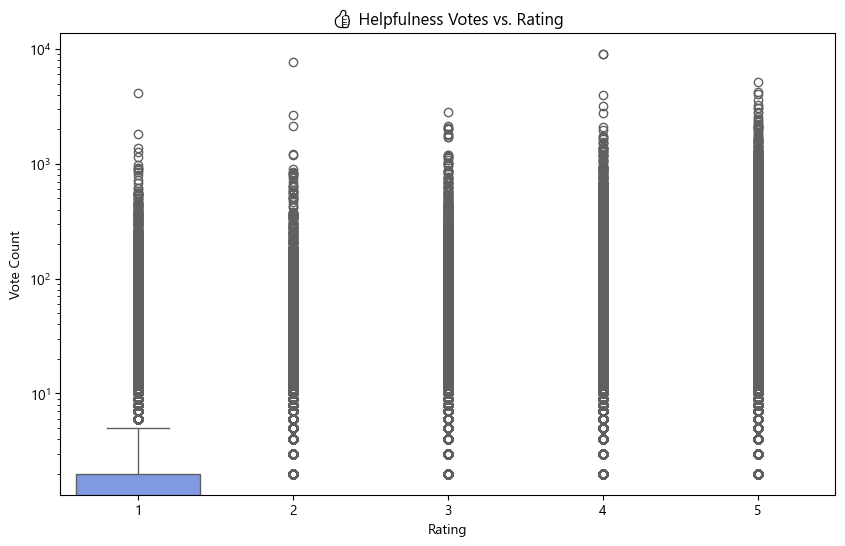

In [59]:
# Ensure numeric
if 'vote' in df3.columns:
    df3['vote'] = pd.to_numeric(df3['vote'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df3, x='overall', y='vote', palette="coolwarm")
plt.title("👍 Helpfulness Votes vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Vote Count")
plt.yscale('log')  # Optional
plt.show()


REVIEW LENGTH VS. RATING

C:\Users\prave\AppData\Local\Temp\ipykernel_29036\3976541759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df3, x='overall', y='review_length', palette="viridis")


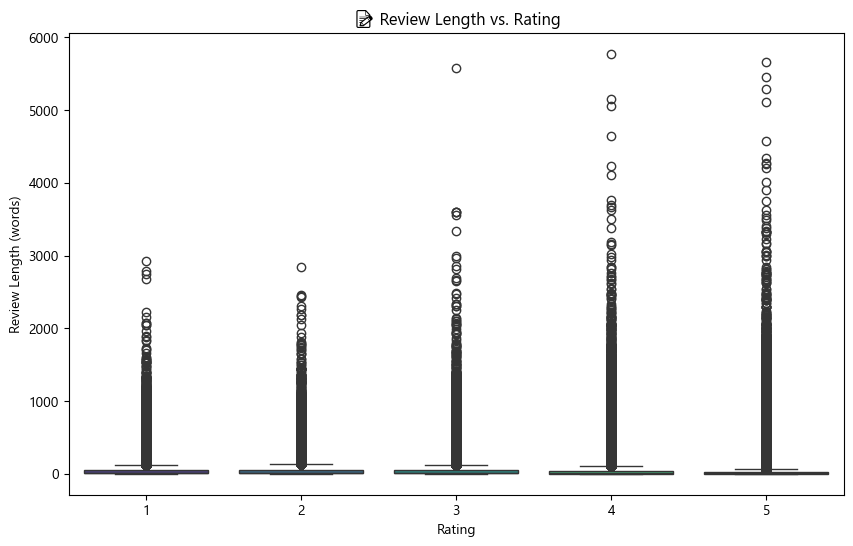

In [58]:
df3['review_length'] = df3['full_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df3, x='overall', y='review_length', palette="viridis")
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()

VERIFIED VS. UNVERIFIED RATING

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


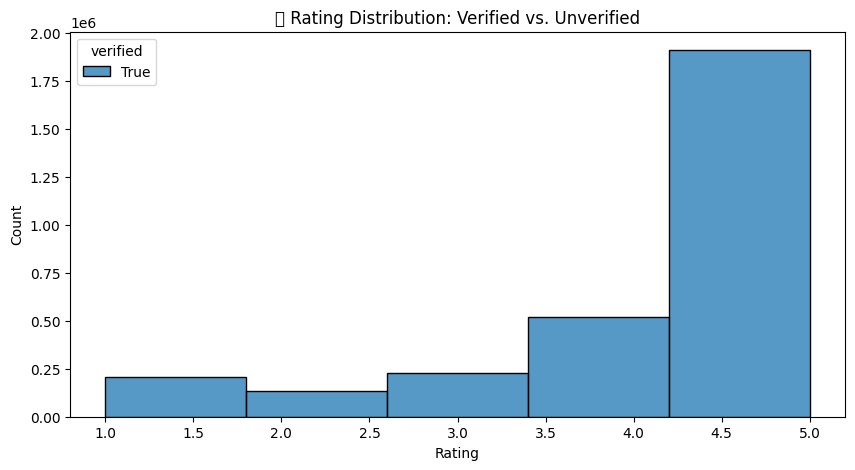

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df3, x='overall', hue='verified', multiple='stack', bins=5)
plt.title("🔍 Rating Distribution: Verified vs. Unverified")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

REMOVING THE UNNECESSARY COLUMNS

In [ ]:
df3=df3.drop(columns=[ 'vote', 'verified', 'reviewTime',  'summary'])

CHECKING NULL VALUES

In [ ]:
df3.isnull().sum()

,0
overall,0
reviewText,462


REMOVING NULL VALUES

In [ ]:
df3.dropna(inplace=True)

CHECKING DUPLICATES

In [ ]:
print(df3.duplicated().sum())

932118


RENAMING THE COLUMNS

In [ ]:
df3.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

DROPPING DUPLICATES

In [ ]:
df3.drop_duplicates(subset=['review','rating'],inplace=True)

In [ ]:
df3['rating']=df3['rating'].astype(int)

REMOVING EMOJIS,LINKS

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df3.loc[:, "review"] = df3["review"].apply(clean_text)

In [ ]:
df3['rating'].value_counts()

,count
rating,
5,1226966
4,382301
3,181352
1,163190
2,113611


In [ ]:
df3.shape

(2067420, 2)

In [ ]:
df3.to_csv('cleaned_electronics_small.csv',index=False)

LOADING THE DATASET-4

In [12]:
import pandas as pd
df4=pd.read_csv(r'C:\Users\prave\Downloads\electronics review\amazon_electronics.csv')
df4.head(5)

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,22873041,R3ARRMDEGED8RD,B00KJWQIIC,335625766,Plemo 14-Inch Laptop Sleeve Case Waterproof Fa...,PC,5,0,0,N,Y,Pleasantly surprised,I was very surprised at the high quality of th...,2015-08-31,1
1,US,30088427,RQ28TSA020Y6J,B013ALA9LA,671157305,TP-Link OnHub AC1900 Wireless Wi-Fi Router,PC,5,24,31,N,N,OnHub is a pretty no nonsense type router that...,I am a Google employee and had to chance to us...,2015-08-31,1
2,US,20329786,RUXJRZCT6953M,B00PML2GQ8,982036237,AmazonBasics USB 3.0 A Male to A Male Cable - ...,PC,1,2,2,N,N,None of them worked. No functionality at all.,"Bought cables in 3ft, 6ft and 9ft. NONE of th...",2015-08-31,0
3,US,14215710,R7EO0UO6BPB71,B001NS0OZ4,576587596,Transcend P8 15-in-1 USB 2.0 Flash Memory Card...,PC,1,0,0,N,Y,just keep searching.,"nope, cheap and slow",2015-08-31,0
4,US,38264512,R39NJY2YJ1JFSV,B00AQMTND2,964759214,Aleratec SATA Data Cable 2.0 20in Serial ATA S...,PC,5,0,0,N,Y,Five Stars,Excellent! Great value and does the job.,2015-08-31,1


In [ ]:
df4.tail(5)

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
6906559,US,51995596,R3N6GRSJKEASQP,B00000J3II,672369061,Iomega 10919 Zip 100 Drive (Parallel Port),PC,5,4,4,N,N,Sturdy and Useful.,I've owned the Zip drive for 3 years already a...,1999-07-10,1
6906560,US,51709569,R3D1N3J5SXSYPF,B00000J3II,672369061,Iomega 10919 Zip 100 Drive (Parallel Port),PC,4,1,2,N,N,"good, but could be better",i bought one of these to backup my ever growin...,1999-07-02,1
6906561,US,52013515,R2X34TXZ6RML4Q,B00000J3II,672369061,Iomega 10919 Zip 100 Drive (Parallel Port),PC,3,5,5,N,N,"Nice for beginners, JAZ is better",I bought this because my hard drive was runnin...,1999-07-02,0
6906562,US,52851668,R3AZ2KXYCYXMYL,B00000JBHA,865091807,Yamaha YSTMS28W Multimedia Speakers,PC,5,15,15,N,N,"great sounding deep bass, clear highend, nothi...",i use these speakers with my macintosh pc and ...,1999-07-01,1
6906563,US,52133593,R331BOV1QBPB9D,B00000JDFI,978603818,Belkin Pro Series Parallel Printer Cable (25 F...,PC,5,12,13,N,N,One nice cable,"Belkin cables are the best! They have big, ea...",1999-07-01,1


In [ ]:
df4.sample(5)

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
4009468,US,17709184,RINO1Z5SG1VGD,B001NXDBI6,517898090,Logitech G19 Programmable Gaming Keyboard with...,PC,3,0,0,N,Y,This model takes some steps backwards from it'...,This gets a 3 as a user of other G series keyb...,2013-12-03,0
1516009,US,539457,R27VHOSE54IKT,B00KVIXCCO,725127936,TP-LINK Universal Wireless Range Extender,PC,5,0,0,N,Y,Five Stars,Works very good!!,2015-02-08,1
859437,US,41587091,R262U0DUWZC82C,B00BGIQS1A,654667116,Amazon Kindle 5W USB Power Adapter,PC,5,0,0,N,N,It works.,"Well, what can I say? It works. It's supposed ...",2015-04-30,1
2832900,US,47791225,RJSRJLEFBV768,B006YG90RI,858559827,Crucial 16GB Kit (8GBx2) DDR3 1333 MT/s (PC3-1...,PC,5,0,0,N,Y,Excellent product,Worked perfectly for my needs in a NAS box. Be...,2014-08-07,1
4976358,US,52645872,R1260AI2E5EK2D,B008DWYBZM,755623424,Bear Motion ® Luxury 100% Genuine Top Layer Bu...,PC,4,0,1,N,Y,Excellent but needs pen clip,Excellent. 5 stars for what it is but 4 start...,2013-03-02,1


In [ ]:
df4.shape

(6906564, 16)

In [ ]:
df4.describe()

,customer_id,product_parent,star_rating,helpful_votes,total_votes,sentiment
count,6.906564e+06,6.906564e+06,6.906564e+06,6.906564e+06,6.906564e+06,6.906564e+06
mean,2.799257e+07,4.916634e+08,4.086461e+00,1.484451e+00,1.962077e+00,7.636062e-01
std,1.557220e+07,2.890112e+08,1.362854e+00,4.149143e+01,4.307079e+01,4.248668e-01
min,1.001600e+04,1.602000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.442019e+07,2.428900e+08,4.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
50%,2.678854e+07,4.884428e+08,5.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,4.266215e+07,7.429021e+08,5.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,5.309658e+07,9.999960e+08,5.000000e+00,4.752400e+04,4.836200e+04,1.000000e+00


In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6906564 entries, 0 to 6906563
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   marketplace        object
 1   customer_id        int64 
 2   review_id          object
 3   product_id         object
 4   product_parent     int64 
 5   product_title      object
 6   product_category   object
 7   star_rating        int64 
 8   helpful_votes      int64 
 9   total_votes        int64 
 10  vine               object
 11  verified_purchase  object
 12  review_headline    object
 13  review_body        object
 14  review_date        object
 15  sentiment          int64 
dtypes: int64(6), object(10)
memory usage: 843.1+ MB


COLUMNS NAMES

In [ ]:
df4.columns

Index(['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date', 'sentiment'],
      dtype='object')

 Rating Distribution

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


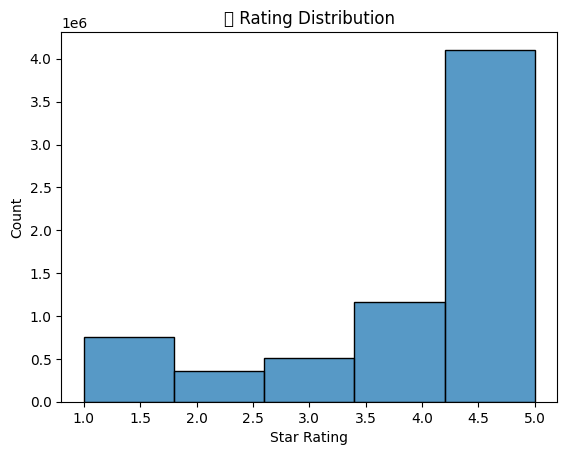

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df4['star_rating'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

Sentiment vs. Rating Consistency

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


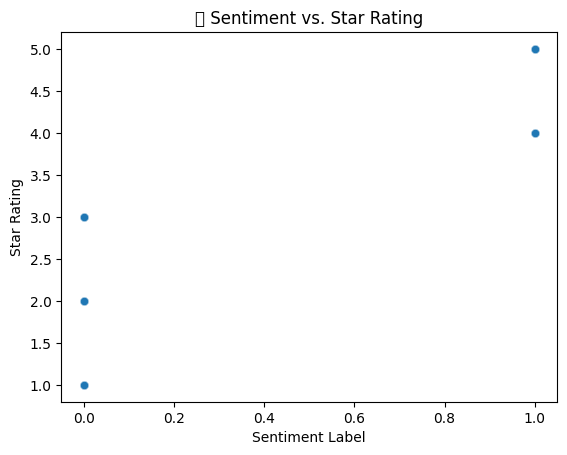

In [15]:
sns.scatterplot(data=df4, x='sentiment', y='star_rating', alpha=0.3)
plt.title("🧠 Sentiment vs. Star Rating")
plt.xlabel("Sentiment Label")
plt.ylabel("Star Rating")
plt.show()

Review Length vs. Rating

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


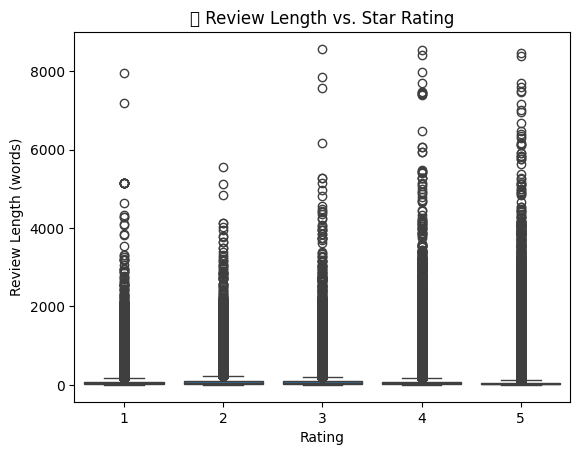

In [16]:
df4['length'] = df4['review_body'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df4, x='star_rating', y='length')
plt.title("📝 Review Length vs. Star Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()

Helpfulness vs. Rating

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


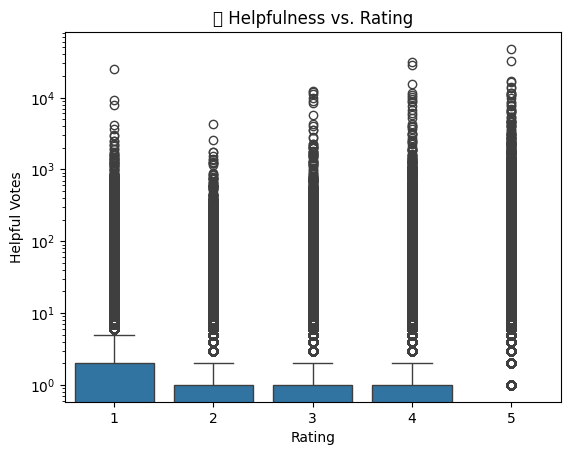

In [17]:
sns.boxplot(data=df4, x='star_rating', y='helpful_votes')
plt.title("👍 Helpfulness vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.yscale('log')
plt.show()

Category-Level Rating Trends

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


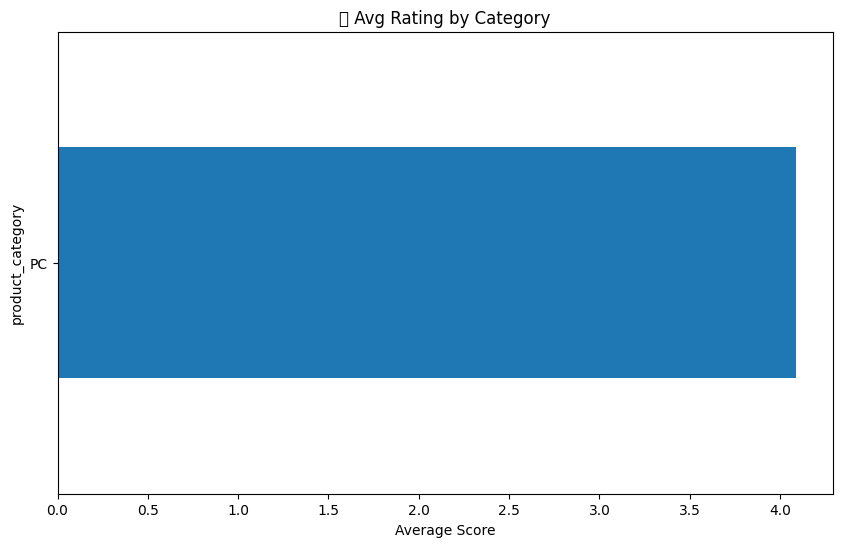

In [19]:
category_avg = df4.groupby('product_category')['star_rating'].mean().sort_values()
category_avg.plot(kind='barh', figsize=(10, 6), title="📚 Avg Rating by Category")
plt.xlabel("Average Score")
plt.show()

Review Bias (Vine)

C:\Users\prave\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127873 (\N{WRAPPED PRESENT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


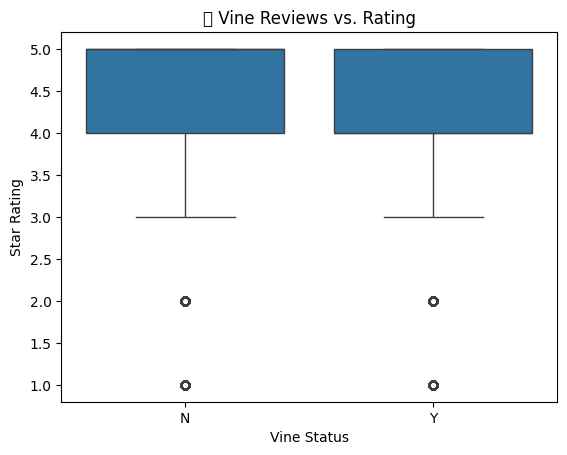

In [20]:
sns.boxplot(data=df4, x='vine', y='star_rating')
plt.title("🎁 Vine Reviews vs. Rating")
plt.xlabel("Vine Status")
plt.ylabel("Star Rating")
plt.show()

REMOVING THE UNNECESSARY COLUMNS

In [ ]:
df4=df4.drop(columns=['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_date', 'sentiment' ])

CHECKING NULL VALUES

In [ ]:
df4.isnull().sum()

,0
star_rating,0
review_body,120


REMOVING NULL VALUES

In [ ]:
df4.dropna(inplace=True)

CHECKING DUPLICATES

In [ ]:
print(df4.duplicated().sum())

500523


DROPPING DUPLICATES

In [ ]:
df4.drop_duplicates(subset=[ 'star_rating', 'review_body'],inplace=True)

RENAMING THE COLUMNS

In [ ]:
df4.rename(columns={ 'review_body':'review','star_rating':'rating'},inplace=True)

In [ ]:
df4['rating']=df4['rating'].astype(int)

REMOVING EMOJIS,LINKS

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df4.loc[:, "review"] = df4["review"].apply(clean_text)

In [ ]:
df4['rating'].value_counts()

,count
rating,
5,3694309
4,1110817
1,740559
3,501390
2,358846


In [ ]:
df4.shape

(6405921, 2)

In [ ]:
df4.to_csv('clean_amazon_electronics.csv',index=False)